# CS4452 Assignment 3: Anomaly Detection

### 

##### Dependencies & Modules

In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from sklearn.metrics import roc_auc_score, accuracy_score


In [2]:
# Use seed 42 as required by the assignment
torch.manual_seed(42)
np.random.seed(42)

class ColorMNIST(Dataset):
    def __init__(self, root, train=True, transform=None, target_transform=None, download=False):
        self.mnist = datasets.MNIST(root, train=train, download=download)
        self.transform = transform

    def __getitem__(self, index):
        img, target = self.mnist[index]
        img = np.array(img)
        
        # Colorization logic from practice code
        colored_img = np.zeros((3, 28, 28), dtype=np.float32)
        color = np.random.choice([0, 1, 2])
        colored_img[color, :, :] = img / 255.0
        
        if self.transform:
            colored_img = torch.from_numpy(colored_img)
        
        return colored_img, target

    def __len__(self):
        return len(self.mnist)

#### MNIST dataset


In [3]:
mnist_transform = transforms.Compose([
    transforms.ToTensor()
])
train_mnist = MNIST(
    root="./data",
    train=True,
    download=True,
    transform=mnist_transform
)

test_mnist = MNIST(
    root="./data",
    train=False,
    download=True,
    transform=mnist_transform
)

### Part A: Autoencoder Training

Starting training...
Epoch [1/5], Loss: 0.0476
Epoch [2/5], Loss: 0.0070
Epoch [3/5], Loss: 0.0040
Epoch [4/5], Loss: 0.0030
Epoch [5/5], Loss: 0.0025


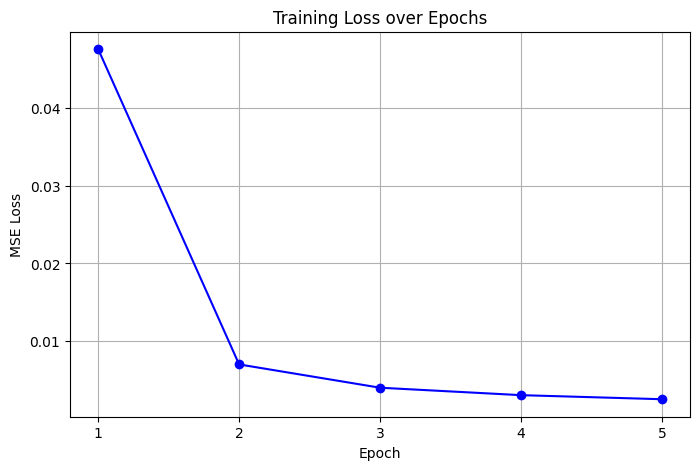

In [4]:


# 1. Define the ConvAutoencoder
class ConvAutoencoder(nn.Module):
    def __init__(self, feature_dim=128):
        super().__init__()

        # Encoder
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),   # (B, 3, 28, 28) -> (B, 32, 14, 14)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # -> (B, 64, 7, 7)
            nn.ReLU()
        )

        self.encoder_flatten = nn.Flatten()
        self.encoder_fc = nn.Linear(64 * 7 * 7, feature_dim)

        # Decoder
        self.decoder_fc = nn.Linear(feature_dim, 64 * 7 * 7)
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # -> (B, 32, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),   # -> (B, 3, 28, 28)
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_cnn(x)
        x = self.encoder_flatten(x)
        z = self.encoder_fc(x)
        return z

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, 64, 7, 7)
        x = self.decoder_cnn(x)
        return x

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon

# 2. Setup Device, Model, DataLoader, and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

ae_model = ConvAutoencoder(feature_dim=128).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)

# Use standard MNIST as requested
train_loader = DataLoader(train_mnist, batch_size=256, shuffle=True)

# 3. Training Loop
num_epochs = 5
epoch_losses = []

print("Starting training...")
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, _ in train_loader:
        # Repeat the 1-channel MNIST to 3 channels to match the provided model
        images = images.repeat(1, 3, 1, 1).to(device) 
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = ae_model(images)
        loss = criterion(outputs, images)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

# 4. Plot the training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', linestyle='-', color='b')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.xticks(range(1, num_epochs + 1))
plt.grid(True)
plt.show()

### Part B: Reconstruction Error Analysis

Average Reconstruction Error (MNIST): 0.002281
Average Reconstruction Error (ColorMNIST): 0.028419


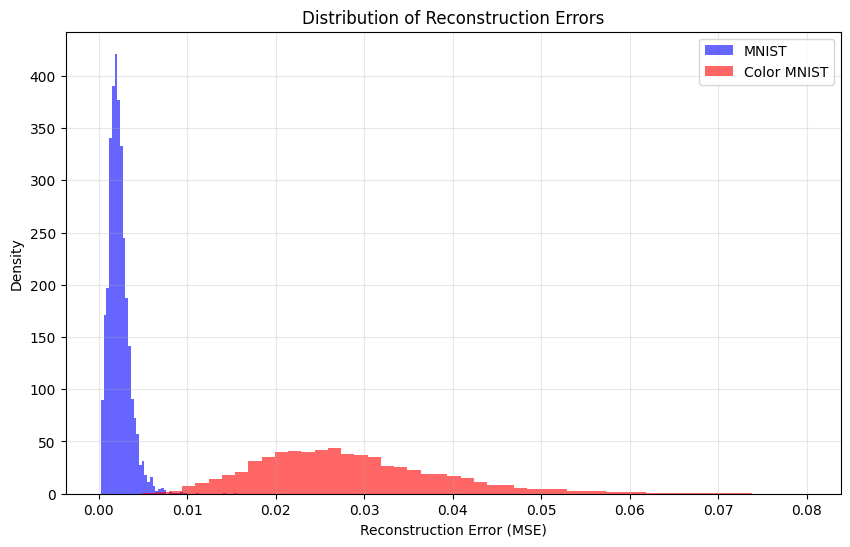

In [5]:

test_loader_mnist = DataLoader(test_mnist, batch_size=256, shuffle=False)
test_color_mnist = ColorMNIST(root="./data", train=False, download=True, transform=True)
test_loader_color = DataLoader(test_color_mnist, batch_size=256, shuffle=False)

def evaluate_reconstruction_errors(model, dataloader, repeat_channels=False):
    model.eval()
    all_errors = []
    with torch.no_grad():
        for images, _ in dataloader:
            if repeat_channels:
                images = images.repeat(1, 3, 1, 1)
            images = images.to(device)
            reconstructed = model(images)
            mse_per_image = torch.mean((images - reconstructed) ** 2, dim=[1, 2, 3])
            all_errors.extend(mse_per_image.cpu().numpy())
    return np.array(all_errors)

mnist_errors = evaluate_reconstruction_errors(ae_model, test_loader_mnist, repeat_channels=True)
color_errors = evaluate_reconstruction_errors(ae_model, test_loader_color, repeat_channels=False)

avg_mnist_error = np.mean(mnist_errors)
avg_color_error = np.mean(color_errors)

print(f"Average Reconstruction Error (MNIST): {avg_mnist_error:.6f}")
print(f"Average Reconstruction Error (ColorMNIST): {avg_color_error:.6f}")

plt.figure(figsize=(10, 6))
plt.hist(mnist_errors, bins=50, alpha=0.6, label='MNIST', color='blue', density=True)
plt.hist(color_errors, bins=50, alpha=0.6, label='Color MNIST', color='red', density=True)
plt.title('Distribution of Reconstruction Errors')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

### Part C: Anomaly Detection

In [6]:
# 1. Create true labels: 0 for normal (MNIST), 1 for anomaly (ColorMNIST)
true_labels_mnist = np.zeros(len(mnist_errors))
true_labels_color = np.ones(len(color_errors))

# Combine the labels and the reconstruction errors (scores)
y_true = np.concatenate([true_labels_mnist, true_labels_color])
y_scores = np.concatenate([mnist_errors, color_errors])

# 2. Compute the AUROC
auroc = roc_auc_score(y_true, y_scores)
print(f"AUROC: {auroc:.4f}")

# 3. Define the threshold as the 95th percentile of MNIST reconstruction errors
threshold = np.percentile(mnist_errors, 95)
print(f"Anomaly Threshold (95th percentile of MNIST): {threshold:.6f}")

# 4. Classify based on threshold (error > threshold -> anomaly, else -> normal)
y_pred = (y_scores > threshold).astype(int)

# 5. Report detection accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Detection Accuracy: {accuracy:.4f}")

AUROC: 1.0000
Anomaly Threshold (95th percentile of MNIST): 0.004376
Detection Accuracy: 0.9750


### Part D: Visualization

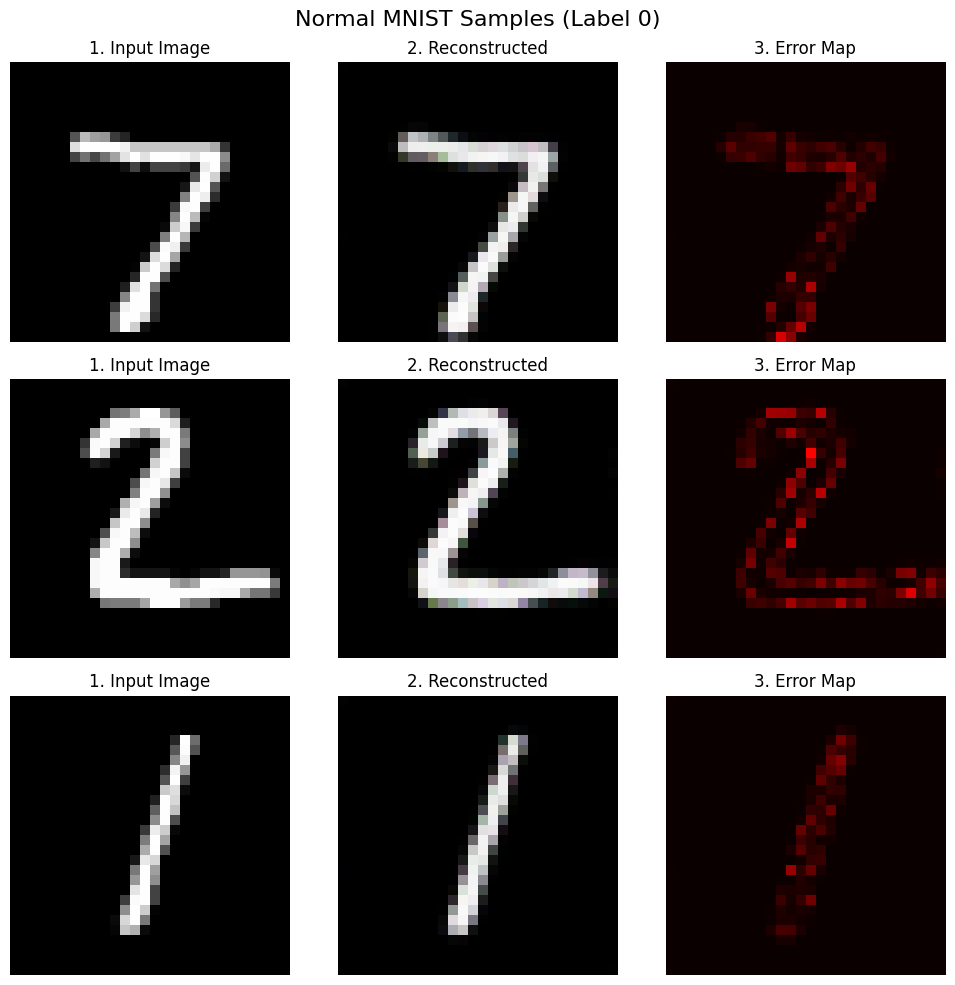

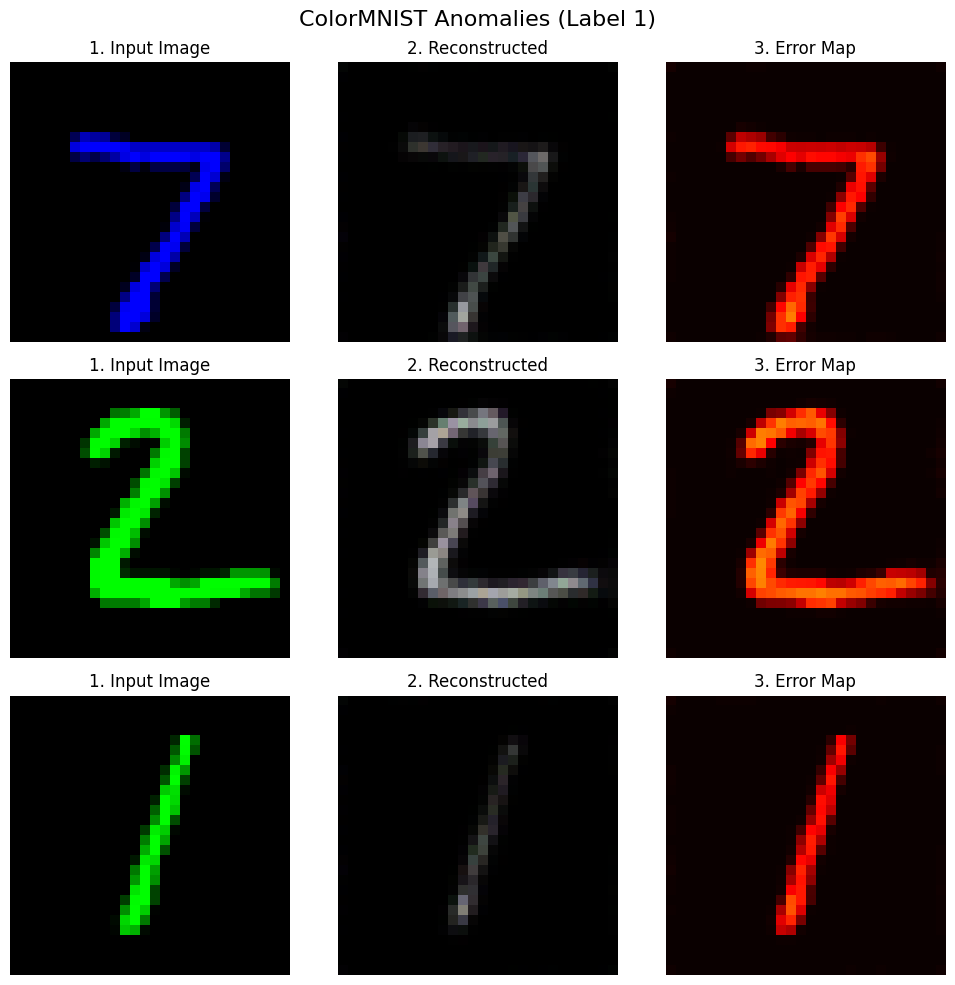

In [7]:
# 1. Extract a single batch of data from our test loaders
mnist_iter = iter(test_loader_mnist)
mnist_images, _ = next(mnist_iter)

color_iter = iter(test_loader_color)
color_images, _ = next(color_iter)

# Select the first 3 images from each batch
mnist_samples = mnist_images[:3]
color_samples = color_images[:3]

# 2. Format inputs to 3-channels and move to the correct device
mnist_samples_3c = mnist_samples.repeat(1, 3, 1, 1).to(device)
color_samples = color_samples.to(device)

# 3. Get the model's reconstructions (use no_grad since we are just evaluating)
ae_model.eval()
with torch.no_grad():
    mnist_recon = ae_model(mnist_samples_3c)
    color_recon = ae_model(color_samples)

# 4. Helper function to plot exactly what is requested
def plot_reconstructions(originals, reconstructions, title_prefix):
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
    fig.suptitle(f"{title_prefix}", fontsize=16)
    
    for i in range(3):
        # Neural network images are shape (Channels, Height, Width)
        # Matplotlib needs (Height, Width, Channels), so we use .permute(1, 2, 0)
        orig_img = originals[i].cpu().permute(1, 2, 0).numpy()
        recon_img = reconstructions[i].cpu().permute(1, 2, 0).numpy()
        
        # Calculate Error Map: Absolute difference between original and reconstruction.
        # We take the mean across the color axis (axis=2) to make it a 2D intensity heatmap.
        error_map = np.abs(orig_img - recon_img).mean(axis=2)
        
        # Plot Original
        axes[i, 0].imshow(np.clip(orig_img, 0, 1))
        axes[i, 0].set_title("1. Input Image")
        axes[i, 0].axis('off')
        
        # Plot Reconstruction
        axes[i, 1].imshow(np.clip(recon_img, 0, 1))
        axes[i, 1].set_title("2. Reconstructed")
        axes[i, 1].axis('off')
        
        # Plot Error Map (using a 'hot' colormap where darker/black = low error, bright = high error)
        im = axes[i, 2].imshow(error_map, cmap='hot', vmin=0, vmax=1)
        axes[i, 2].set_title("3. Error Map")
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

# 5. Generate the plots
plot_reconstructions(mnist_samples_3c, mnist_recon, "Normal MNIST Samples (Label 0)")
plot_reconstructions(color_samples, color_recon, "ColorMNIST Anomalies (Label 1)")

### Part E: Analysis 

##### Why is the reconstruction error typically lower on MNIST than on ColorMNIST?

The autoencoder was trained exclusively on standard, grayscale MNIST images, meaning its learned latent space is optimized specifically to encode and decode white digits on black backgrounds. When presented with ColorMNIST, the model encounters distinct color channel activation patterns it has never seen during training. Because these colored features fall outside the model's learned normal data distribution, it fails to reconstruct them accurately, resulting in a significantly higher reconstruction error.

##### Why can reconstruction error be used as an anomaly score?

An autoencoder learns to correctly compress and reconstruct only the specific types of regular data it was trained on. When an anomalous image is passed through the network, the model's learned weights are ill-equipped to represent the unfamiliar features, inherently causing a poor, loss filled reconstruction. Therefore, the magnitude of the error directly measures how much a given sample deviates from the normal training distribution, making it a highly effective anomaly score.

##### Describe one scenario where reconstruction-based anomaly detection may fail?

Reconstruction-based detection can fail if the autoencoder's bottleneck (latent space feature dimension) is too large, giving the model so much capacity that it simply acts as an identity function. In this scenario, the model might successfully copy and reconstruct both normal and anomalous data flawlessly, resulting in low errors for both and eliminating the gap needed for thresholding. It can also fail if the anomalies are structurally identical to normal data (e.g., a highly sophisticated counterfeit) and don't trigger unfamiliar feature activations.

